In [9]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../scripts").resolve()))
import graph_export


# ---- Change this to switch languages ----
langCodes = ["spa", "arz", "rue"]
# -----------------------------------------

lang_overview = pd.read_csv("../../../results/1_process/2_aggregate/language_overview.csv")

langs = {}
for langCode in langCodes:
    langName = lang_overview.loc[lang_overview["used_shortcut"] == langCode, "name"].values[0]
    df = pd.read_csv(f"../../../data/1_aggregated/{langCode}.csv")
    df = df.sort_values("frequency", ascending=False).reset_index(drop=True)
    df["rank"] = df.index + 1
    df["cumFreq"] = df["frequency"].cumsum()
    totalFreq = df["frequency"].sum()
    df["coverage"] = df["cumFreq"] / totalFreq
    ranks = df["rank"].to_numpy()
    freqs = df["frequency"].to_numpy()
    probs = freqs / totalFreq

    langs[langCode] = {
        "name": langName, "df": df, "ranks": ranks, "freqs": freqs,
        "probs": probs, "totalFreq": totalFreq,
    }
    print(f"{langName} ({langCode}): total_frequency = {totalFreq:,}")


Spanish (spa): total_frequency = 4,778,280,127
Egyptian Arabic (arz): total_frequency = 45,335,001
Rusyn (rue): total_frequency = 1,136,369


In [10]:

# Two sets of cutoffs: "light" and "dark"
cutoffs = {
    "light": {"freq": 100, "rankShare": 0.05, "coverage": 0.95},
    "dark":  {"freq": 10,  "rankShare": 0.30, "coverage": 0.99},
}

all_results = {}

for langCode in langCodes:
    L = langs[langCode]
    ranks = L["ranks"]
    probs = L["probs"]
    totalFreq = L["totalFreq"]
    df = L["df"]

    results = {}
    for label, c in cutoffs.items():
        res = {}

        # 1) Red: frequency cutoff → probability cutoff
        freqThresh = c["freq"]
        probThresh = freqThresh / totalFreq
        redX = None
        for i in range(len(probs) - 1):
            y1, y2 = probs[i], probs[i + 1]
            if y1 >= probThresh >= y2:
                x1, x2 = ranks[i], ranks[i + 1]
                if y1 == y2:
                    redX = x1
                else:
                    redX = x1 + (probThresh - y1) * (x2 - x1) / (y2 - y1)
                break
        if redX is None:
            redX = ranks[-1] if probs[-1] > probThresh else ranks[0]
        res["redX"] = redX
        res["redY"] = probThresh

        # 2) Blue: rank share cutoff
        blueX = c["rankShare"] * len(df)
        blueY = np.interp(blueX, ranks, probs)
        res["blueX"] = blueX
        res["blueY"] = blueY

        # 3) Green: corpus coverage cutoff
        greenIndex = np.argmax(df["coverage"].to_numpy() >= c["coverage"])
        greenX = ranks[greenIndex]
        greenY = probs[greenIndex]
        res["greenIndex"] = greenIndex
        res["greenX"] = greenX
        res["greenY"] = greenY

        results[label] = res
    all_results[langCode] = results


graph_export: saved freq_rank.png


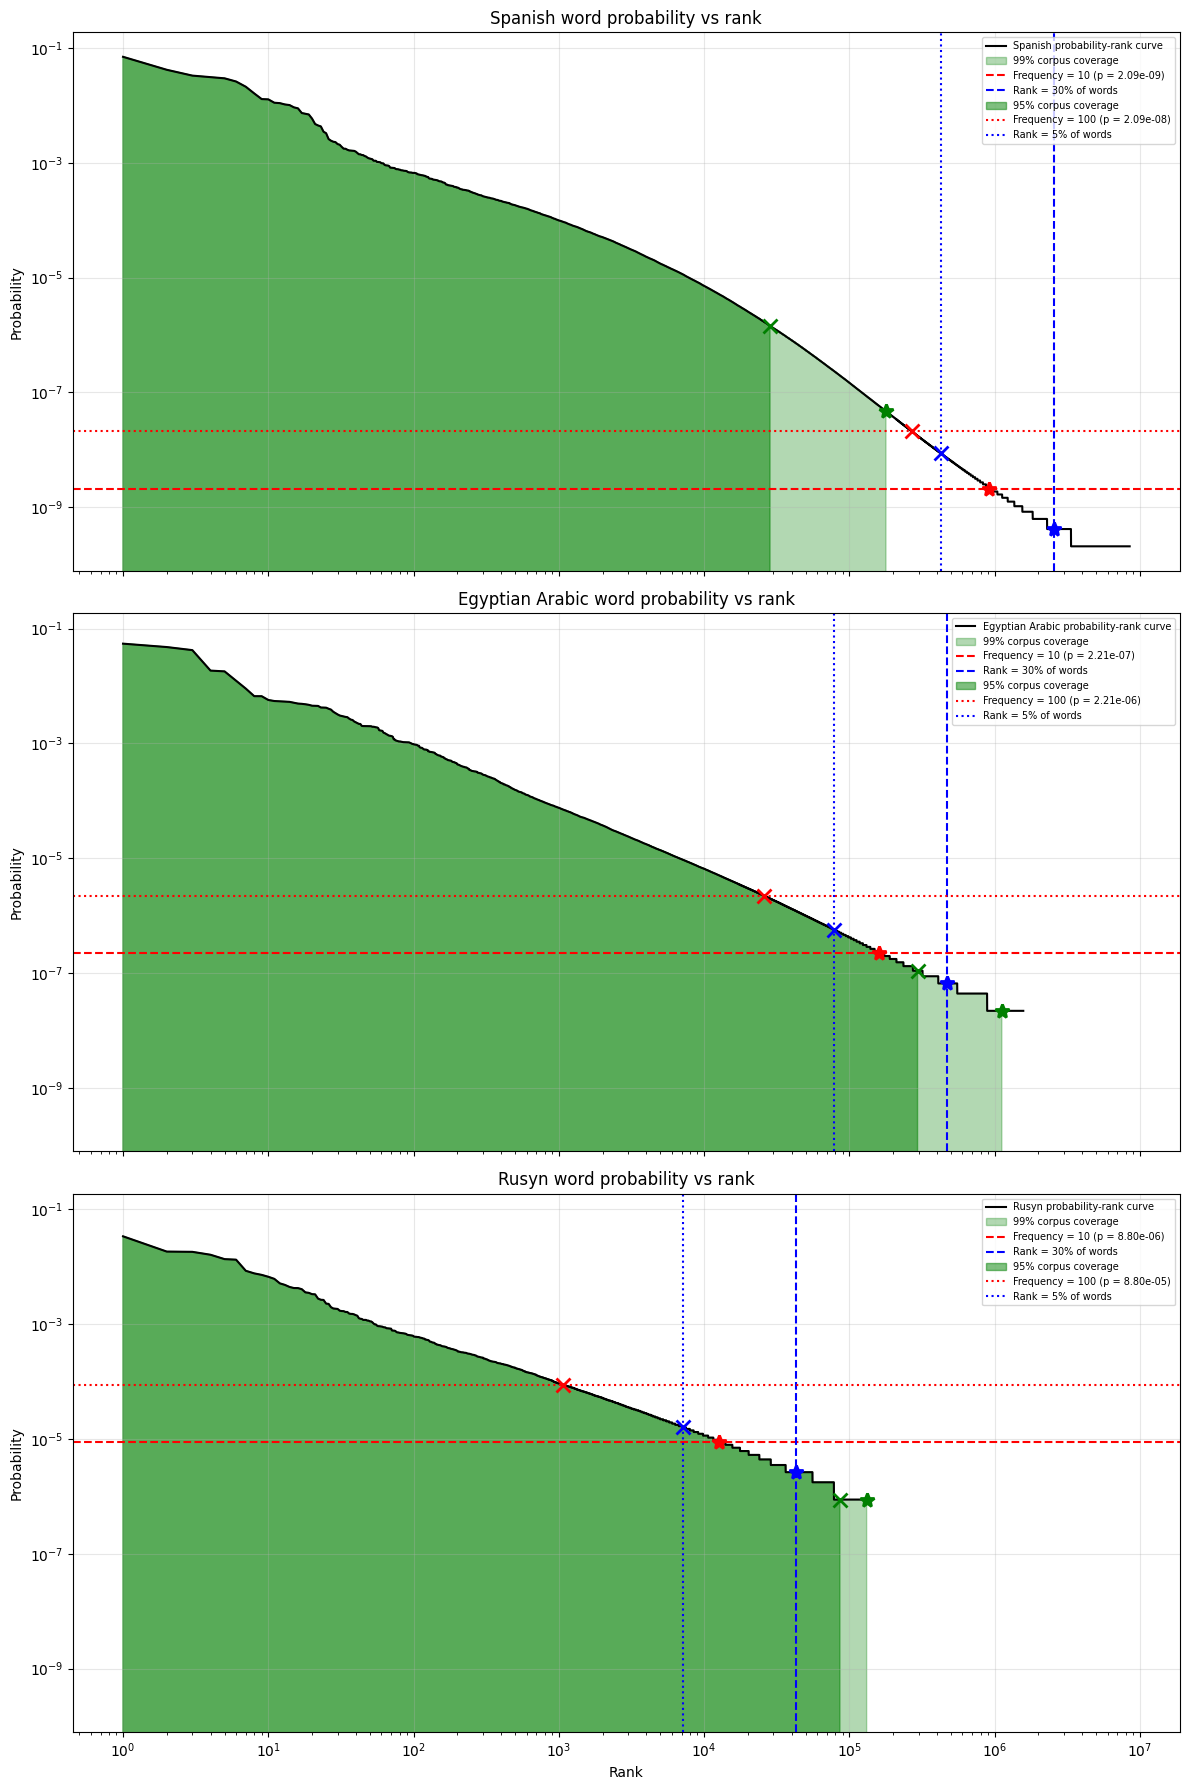


=== Spanish (spa) ===
  [LIGHT]
    Red cross   (freq = 100): rank ≈ 268572.00
    Blue cross  (rank = 5% of words): rank = 424846.15, freq ≈ 0.00
    Green cross (95% coverage): rank = 28409, freq = 1.4513590278672248e-06, words = 28409 (0.33% of vocabulary)
  [DARK]
    Red cross   (freq = 10): rank ≈ 919282.00
    Blue cross  (rank = 30% of words): rank = 2549076.90, freq ≈ 0.00
    Green cross (99% coverage): rank = 178509, freq = 4.72973526024503e-08, words = 178509 (2.10% of vocabulary)

=== Egyptian Arabic (arz) ===
  [LIGHT]
    Red cross   (freq = 100): rank ≈ 25981.00
    Blue cross  (rank = 5% of words): rank = 78677.30, freq ≈ 0.00
    Green cross (95% coverage): rank = 294559, freq = 1.102900604325563e-07, words = 294559 (18.72% of vocabulary)
  [DARK]
    Red cross   (freq = 10): rank ≈ 159754.00
    Blue cross  (rank = 30% of words): rank = 472063.80, freq ≈ 0.00
    Green cross (99% coverage): rank = 1120196, freq = 2.205801208651126e-08, words = 1120196 (71.19% of voc

In [11]:

# -----------------------------
# Stacked plot – shared axes
# -----------------------------
n = len(langCodes)
fig, axes = plt.subplots(n, 1, figsize=(12, 6 * n), sharex=True, sharey=True)
if n == 1:
    axes = [axes]

styles = {
    "light": {"ls": ":", "marker": "x", "fill_alpha": 0.50, "fill_color": "green"},
    "dark":  {"ls": "--", "marker": "*", "fill_alpha": 0.30, "fill_color": "green"},
}

for ax, langCode in zip(axes, langCodes):
    L = langs[langCode]
    ranks = L["ranks"]
    probs = L["probs"]
    totalFreq = L["totalFreq"]
    results = all_results[langCode]

    ax.plot(ranks, probs, color="black", label=f"{L['name']} probability-rank curve")

    for label in ["dark", "light"]:
        c = cutoffs[label]
        r = results[label]
        s = styles[label]

        idx = r["greenIndex"]
        ax.fill_between(
            ranks[:idx + 1], probs[:idx + 1],
            color=s["fill_color"], alpha=s["fill_alpha"],
            label=f"{int(c['coverage'] * 100)}% corpus coverage",
        )

        probThresh = c["freq"] / totalFreq
        ax.axhline(y=probThresh, color="red", linestyle=s["ls"],
                    label=f"Frequency = {c['freq']} (p = {probThresh:.2e})")
        ax.plot(r["redX"], r["redY"], marker=s["marker"], color="red", markersize=10, mew=2)

        ax.axvline(x=r["blueX"], color="blue", linestyle=s["ls"],
                    label=f"Rank = {int(c['rankShare'] * 100)}% of words")
        ax.plot(r["blueX"], r["blueY"], marker=s["marker"], color="blue", markersize=10, mew=2)

        ax.plot(r["greenX"], r["greenY"], marker=s["marker"], color="green", markersize=10, mew=2)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_ylabel("Probability")
    ax.set_title(f"{L['name']} word probability vs rank")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7, loc="upper right")

axes[-1].set_xlabel("Rank")
plt.tight_layout()
graph_export.save("freq_rank", fig)
plt.show()

# Print exact values
for langCode in langCodes:
    L = langs[langCode]
    results = all_results[langCode]
    print(f"\n=== {L['name']} ({langCode}) ===")
    for label in ["light", "dark"]:
        c = cutoffs[label]
        r = results[label]
        print(f"  [{label.upper()}]")
        print(f"    Red cross   (freq = {c['freq']}): rank ≈ {r['redX']:.2f}")
        print(f"    Blue cross  (rank = {int(c['rankShare']*100)}% of words): rank = {r['blueX']:.2f}, freq ≈ {r['blueY']:.2f}")
        pct = r['greenIndex'] + 1
        print(f"    Green cross ({int(c['coverage']*100)}% coverage): rank = {r['greenX']}, freq = {r['greenY']}, words = {pct} ({pct / len(L['df']) * 100:.2f}% of vocabulary)")